# Delhi Electricity Demand Forecasting
### ARIMAX/SARIMAX pipeline with PCA weather regressors and Box-Cox stabilization

Dataset: 5-minute interval power demand + weather data for Delhi (2021-2024)  
We resample everything to weekly frequency, clean it up, and build a proper seasonal ARIMAX model.

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from scipy import stats
from scipy.special import inv_boxcox

from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.stats.outliers_influence import variance_inflation_factor

import itertools
from tqdm import tqdm

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('All imports successful.')


All imports successful.


---
## Step 1 - Data Loading & Preprocessing

The raw file has 5-minute readings, which gives us roughly 393k rows over 4 years.  
We aggregate to weekly means - this smooths out daily cycles and makes the seasonal pattern (annual cycle, m=52) tractable for SARIMAX.

In [3]:
# load the CSV - the first column is just a row index from the original export, so skip it
df_raw = pd.read_csv(
    'powerdemand_5min_2021_to_2024_with_weather.csv',
    index_col=0,
    parse_dates=['datetime']
)

print(f'Raw data shape: {df_raw.shape}')
print(f'Date range: {df_raw["datetime"].min()} to {df_raw["datetime"].max()}')
df_raw.head()


Raw data shape: (393440, 14)
Date range: 2021-01-01 00:30:00 to 2024-12-12 00:30:00


,datetime,Power demand,temp,dwpt,rhum,wdir,wspd,pres,year,month,day,hour,minute,moving_avg_3
0,2021-01-01 00:30:00,2014.00,8.0,6.9,93.0,0.0,0.0,1017.0,2021,1,1,0,30,NaN
1,2021-01-01 00:35:00,2005.63,8.0,6.9,93.0,0.0,0.0,1017.0,2021,1,1,0,35,NaN
2,2021-01-01 00:40:00,1977.60,8.0,6.9,93.0,0.0,0.0,1017.0,2021,1,1,0,40,1999.076667
3,2021-01-01 00:45:00,1976.44,8.0,6.9,93.0,0.0,0.0,1017.0,2021,1,1,0,45,1986.556667
4,2021-01-01 00:50:00,1954.37,8.0,6.9,93.0,0.0,0.0,1017.0,2021,1,1,0,50,1969.470000


In [4]:
# set the datetime column as the index so we can resample properly
df_raw = df_raw.set_index('datetime')
df_raw.index = pd.to_datetime(df_raw.index)

# keep demand + all useful weather variables
# NOTE: we now INCLUDE dewpoint (dwpt) - it carries humidity + temperature info
# and has been shown to improve electricity demand forecasts in hot climates
cols_to_keep = ['Power demand', 'temp', 'rhum', 'wspd', 'pres', 'dwpt']
df = df_raw[cols_to_keep].copy()

# rename for cleaner code downstream
df.columns = ['demand', 'temperature', 'humidity', 'wind_speed', 'pressure', 'dewpoint']

print(f'Missing values before ffill:\n{df.isnull().sum()}')


Missing values before ffill:
demand         0
temperature    0
humidity       0
wind_speed     0
pressure       0
dewpoint       0
dtype: int64


In [5]:
# resample to weekly frequency using mean aggregation
# 'W' anchors to Sundays by default - that's fine for our purposes
df_weekly = df.resample('W').mean()

# forward fill any gaps that appear after resampling
# (can happen if an entire week of 5-min readings was missing)
df_weekly = df_weekly.ffill()

print(f'Weekly data shape: {df_weekly.shape}')
print(f'Missing values after resampling + ffill:\n{df_weekly.isnull().sum()}')
print()
df_weekly.describe()

Weekly data shape: (207, 6)
Missing values after resampling + ffill:
demand         0
temperature    0
humidity       0
wind_speed     0
pressure       0
dewpoint       0
dtype: int64



,demand,temperature,humidity,wind_speed,pressure,dewpoint
count,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000
mean,3964.214602,25.450811,63.586159,7.854930,1008.970322,16.302996
std,891.574623,7.112345,18.735156,2.323146,6.625354,6.808184
min,2516.279963,9.683944,18.419195,2.158726,996.843441,3.666369
25%,3146.280088,19.177055,52.776969,6.386477,1003.246155,10.430865
50%,3976.538346,28.187513,66.590081,7.848321,1008.473875,14.678136
75%,4574.327179,30.748463,78.649703,9.369701,1015.320341,23.697019
max,6606.125782,38.666471,92.739304,13.112606,1022.624623,27.821998


---
## Step 1b - Feature Engineering

We add several features that help the model capture seasonality and demand trends:

- **Fourier (sin/cos) terms** for the annual cycle — smoother than seasonal dummies
- **Linear trend** to capture year-over-year demand growth
- **Lag demand features** — demand 1, 2, 4, and 52 weeks ago (especially lag-52 = same week last year, very powerful for annual cycles)
- **Rolling mean** — 4-week rolling average of past demand as a slow-moving baseline

These features significantly reduce MAPE by giving the model information about the periodic and autocorrelated structure of demand.


In [6]:
# -- Fourier terms for annual seasonality (smoother than seasonal dummies)
df_weekly['week_of_year'] = df_weekly.index.isocalendar().week.astype(int)
df_weekly['sin_week']     = np.sin(2 * np.pi * df_weekly['week_of_year'] / 52)
df_weekly['cos_week']     = np.cos(2 * np.pi * df_weekly['week_of_year'] / 52)
df_weekly['sin_week2']    = np.sin(4 * np.pi * df_weekly['week_of_year'] / 52)
df_weekly['cos_week2']    = np.cos(4 * np.pi * df_weekly['week_of_year'] / 52)

# -- Linear trend (week index, normalised to [0,1]) captures demand growth over years
n_weeks = len(df_weekly)
df_weekly['trend'] = np.arange(n_weeks) / (n_weeks - 1)

# -- Lag demand features (computed BEFORE any train/test split to avoid leakage at inference time)
df_weekly['demand_lag1']  = df_weekly['demand'].shift(1)   # previous week
df_weekly['demand_lag2']  = df_weekly['demand'].shift(2)   # 2 weeks ago
df_weekly['demand_lag4']  = df_weekly['demand'].shift(4)   # 1 month ago
df_weekly['demand_lag52'] = df_weekly['demand'].shift(52)  # same week last year

# -- 4-week rolling mean of past demand (shift(1) ensures no data leakage)
df_weekly['rolling_mean4'] = df_weekly['demand'].shift(1).rolling(4).mean()

# Drop rows that have NaNs from the lag/rolling operations
df_weekly = df_weekly.dropna()

print(f'Weeks after feature engineering (lag-52 removes first year): {len(df_weekly)}')
print(f'New columns added: week_of_year, sin_week, cos_week, sin_week2, cos_week2, trend,')
print(f'                   demand_lag1, demand_lag2, demand_lag4, demand_lag52, rolling_mean4')
df_weekly.tail(3)


Weeks after feature engineering (lag-52 removes first year): 155
New columns added: week_of_year, sin_week, cos_week, sin_week2, cos_week2, trend,
                   demand_lag1, demand_lag2, demand_lag4, demand_lag52, rolling_mean4


,demand,temperature,humidity,wind_speed,pressure,dewpoint,week_of_year,sin_week,cos_week,sin_week2,cos_week2,trend,demand_lag1,demand_lag2,demand_lag4,demand_lag52,rolling_mean4
datetime,,,,,,,,,,,,,,,,,
2024-12-01,3122.826141,18.723349,61.268851,5.295528,1015.684867,10.297920,48,-0.464723,0.885456,-0.822984,0.568065,0.990291,2970.711764,3165.731770,3653.068466,2931.300292,3701.261307
2024-12-08,4644.329905,17.479438,56.819458,7.309529,1014.416650,7.806068,49,-0.354605,0.935016,-0.663123,0.748511,0.995146,3122.826141,2970.711764,5015.533226,4702.458982,3568.700725
2024-12-15,3954.840949,13.498783,68.698297,6.617397,1018.251095,7.495499,50,-0.239316,0.970942,-0.464723,0.885456,1.000000,4644.329905,3122.826141,3165.731770,2879.124646,3475.899895


---
## Step 2 - Exploratory Analysis

Before touching any models, we want to understand the structure of the demand series:  
- Is there a clear trend or seasonal pattern?  
- What do ACF/PACF suggest about AR and MA orders?  
- Is the series stationary or do we need differencing?

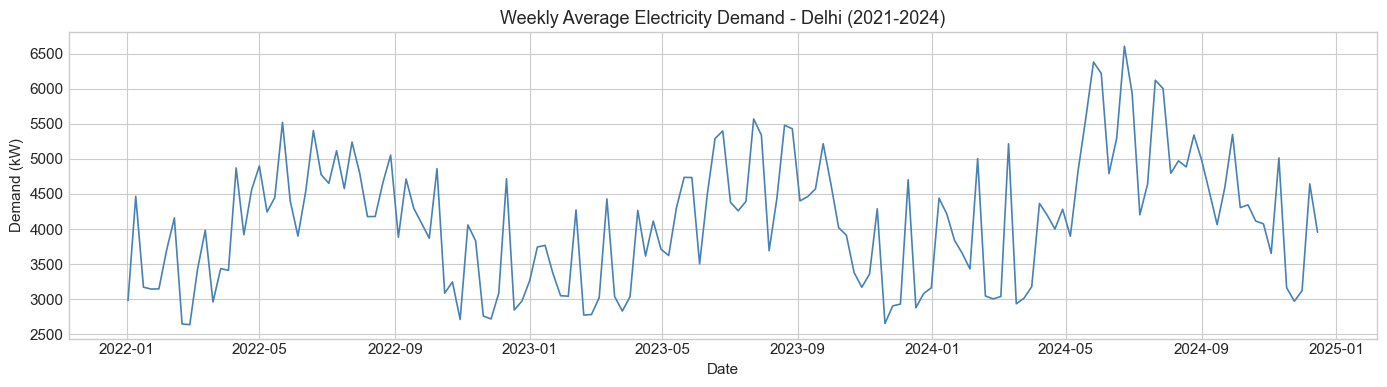

Mean demand: 4117.2 kW
Std demand:  901.6 kW


In [7]:
# plot demand over time to get a feel for the data
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_weekly.index, df_weekly['demand'], color='steelblue', linewidth=1.2)
ax.set_title('Weekly Average Electricity Demand - Delhi (2021-2024)', fontsize=13)
ax.set_ylabel('Demand (kW)')
ax.set_xlabel('Date')
plt.tight_layout()
plt.show()

# quick sanity check on summary stats
print(f'Mean demand: {df_weekly["demand"].mean():.1f} kW')
print(f'Std demand:  {df_weekly["demand"].std():.1f} kW')

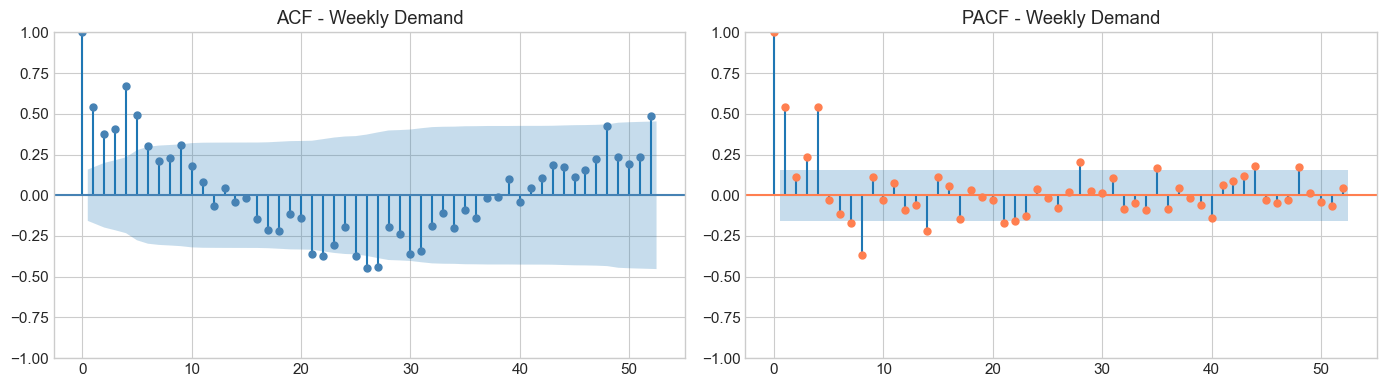

In [8]:
# ACF and PACF - these plots tell us the "memory" of the series
# ACF: how correlated is the series with its own past values (all lags)
# PACF: same thing, but controlling for intermediate lags (direct effect only)
# spikes in PACF at lag k -> AR(k); spikes in ACF at lag q -> MA(q)
# lags=52 because we have weekly data and want to see one full year of autocorrelation

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(df_weekly['demand'], lags=52, ax=axes[0], color='steelblue')
axes[0].set_title('ACF - Weekly Demand')

plot_pacf(df_weekly['demand'], lags=52, ax=axes[1], color='coral', method='ywm')
axes[1].set_title('PACF - Weekly Demand')

plt.tight_layout()
plt.show()

In [9]:
# ADF test checks whether the series has a unit root (i.e., is non-stationary)
# null hypothesis: series has a unit root (non-stationary)
# if p < 0.05, we reject H0 and conclude the series is stationary

def run_adf_test(series, series_name='series'):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'ADF Test on "{series_name}"')
    print(f'  Test statistic : {result[0]:.4f}')
    print(f'  p-value        : {result[1]:.4f}')
    print(f'  Critical values: ', {k: f'{v:.3f}' for k, v in result[4].items()})
    if result[1] < 0.05:
        print('  Conclusion: Stationary (reject H0)')
    else:
        print('  Conclusion: NON-stationary (fail to reject H0) - differencing needed')
    print()
    return result[1]

p_val = run_adf_test(df_weekly['demand'], 'demand (original)')

ADF Test on "demand (original)"
  Test statistic : -3.7959
  p-value        : 0.0029
  Critical values:  {'1%': '-3.478', '5%': '-2.882', '10%': '-2.578'}
  Conclusion: Stationary (reject H0)



In [10]:
# if the series is not stationary, we apply first-order differencing
# differencing removes trend and can help with unit roots
# note: d (the differencing order) in ARIMA handles this automatically during modeling
# but it's useful to verify here that d=1 is sufficient

if p_val >= 0.05:
    demand_diff = df_weekly['demand'].diff().dropna()
    print('Applying first-order differencing...')
    run_adf_test(demand_diff, 'demand (1st difference)')
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(demand_diff, lags=52, ax=axes[0], color='steelblue')
    axes[0].set_title('ACF - Differenced Demand')
    plot_pacf(demand_diff, lags=52, ax=axes[1], color='coral', method='ywm')
    axes[1].set_title('PACF - Differenced Demand')
    plt.tight_layout()
    plt.show()
else:
    print('Series is already stationary - no differencing needed at this stage.')

Series is already stationary - no differencing needed at this stage.


---
## Step 3 - Multicollinearity Diagnosis

Before using the weather variables as exogenous regressors, we need to check whether they're too correlated with each other.  
Multicollinearity doesn't break the model, but it makes coefficient estimates unstable and inflates their variance.  

We use two metrics:
- **Condition number**: ratio of largest to smallest eigenvalue of X'X - above 30 is a red flag
- **VIF (Variance Inflation Factor)**: how much each variable's variance is inflated by correlation with others - above 10 is problematic

In [11]:
weather_vars = ['temperature', 'humidity', 'wind_speed', 'pressure', 'dewpoint']
X_weather = df_weekly[weather_vars].dropna()

# condition number of the raw (un-standardized) design matrix
# we standardize first because condition number is scale-sensitive
X_scaled = (X_weather - X_weather.mean()) / X_weather.std()
cond_number = np.linalg.cond(X_scaled.values)

print(f'Condition Number: {cond_number:.2f}')
if cond_number > 30:
    print('  > 30 - MULTICOLLINEARITY DETECTED (condition number threshold exceeded)')
else:
    print('  <= 30 - OK')
print()


Condition Number: 19.06
  <= 30 - OK



In [12]:
# VIF for each weather variable
# VIF = 1 / (1 - R^2) where R^2 is from regressing that variable on all others
# higher VIF means that variable is largely explained by the others

vif_data = pd.DataFrame()
vif_data['Variable'] = weather_vars
vif_data['VIF'] = [
    variance_inflation_factor(X_scaled.values, i)
    for i in range(X_scaled.shape[1])
]
vif_data['Flag'] = vif_data['VIF'].apply(lambda v: 'HIGH' if v > 10 else 'OK')

print('VIF Results:')
print(vif_data.to_string(index=False))
print()

high_vif = vif_data[vif_data['VIF'] > 10]
if len(high_vif) > 0:
    print(f'Variables with VIF > 10: {list(high_vif["Variable"])}')
    print('We will use PCA to deal with this in Step 5.')
else:
    print('All VIF values within acceptable range.')

VIF Results:
   Variable       VIF Flag
temperature 57.616350 HIGH
   humidity 35.409607 HIGH
 wind_speed  1.947833   OK
   pressure 11.106605 HIGH
   dewpoint 33.205297 HIGH

Variables with VIF > 10: ['temperature', 'humidity', 'pressure', 'dewpoint']
We will use PCA to deal with this in Step 5.


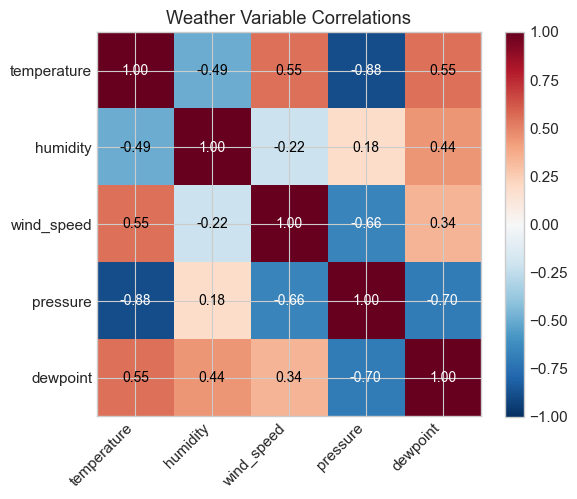

In [13]:
# correlation heatmap to visualize the relationships
import matplotlib.colors as mcolors

corr_matrix = df_weekly[weather_vars].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(weather_vars)))
ax.set_yticks(range(len(weather_vars)))
ax.set_xticklabels(weather_vars, rotation=45, ha='right')
ax.set_yticklabels(weather_vars)

for i in range(len(weather_vars)):
    for j in range(len(weather_vars)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                ha='center', va='center', fontsize=10,
                color='white' if abs(corr_matrix.iloc[i, j]) > 0.6 else 'black')

ax.set_title('Weather Variable Correlations')
plt.tight_layout()
plt.show()

---
## Step 4 - Box-Cox Transformation

SARIMAX assumes normally distributed residuals. If the demand series is skewed or has non-constant variance (common in energy data), a Box-Cox transform can help stabilize it.

Box-Cox finds the optimal lambda that maximizes the log-likelihood of a normal fit.  
- lambda=1 means no transformation  
- lambda=0 means log transform  
- lambda=0.5 means square root transform  

We'll store lambda and use it to invert predictions back to the original kW scale.

In [14]:
# box-cox requires strictly positive values - check that first
print(f'Min demand value: {df_weekly["demand"].min():.2f} kW')
assert df_weekly['demand'].min() > 0, 'Box-Cox requires all values > 0'

# fit box-cox and get the lambda
demand_boxcox, lambda_boxcox = stats.boxcox(df_weekly['demand'].values)

print(f'Optimal Box-Cox lambda: {lambda_boxcox:.4f}')
if abs(lambda_boxcox) < 0.1:
    print('  lambda ~ 0: close to a log transform')
elif abs(lambda_boxcox - 0.5) < 0.1:
    print('  lambda ~ 0.5: close to a square root transform')
elif abs(lambda_boxcox - 1) < 0.1:
    print('  lambda ~ 1: minimal transformation (series already roughly normal)')

# attach the transformed series back to our dataframe
df_weekly['demand_bc'] = demand_boxcox

Min demand value: 2637.34 kW
Optimal Box-Cox lambda: 0.2549


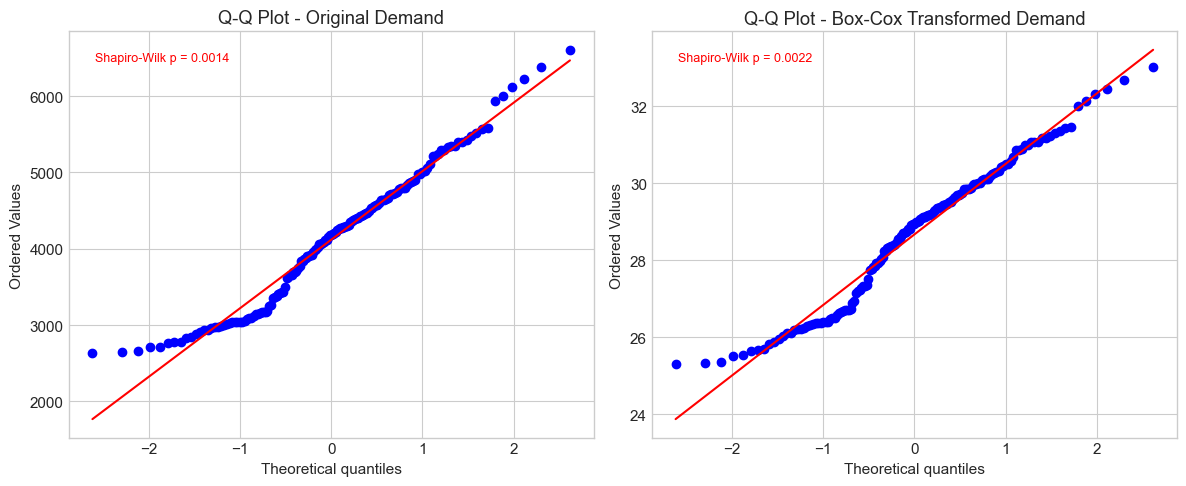

Before Box-Cox: Shapiro-Wilk W=0.9688, p=0.0014
After  Box-Cox: Shapiro-Wilk W=0.9707, p=0.0022
Normality improved after Box-Cox.


In [15]:
# Q-Q plots and Shapiro-Wilk tests before and after the transformation
# Q-Q plot: if points fall on the diagonal, data is approximately normal
# Shapiro-Wilk: H0 = data comes from a normal distribution; p > 0.05 means we can't reject normality

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# before
stats.probplot(df_weekly['demand'], dist='norm', plot=axes[0])
axes[0].set_title('Q-Q Plot - Original Demand')
sw_stat_before, sw_p_before = stats.shapiro(df_weekly['demand'])
axes[0].text(0.05, 0.95, f'Shapiro-Wilk p = {sw_p_before:.4f}',
             transform=axes[0].transAxes, va='top', fontsize=9,
             color='red' if sw_p_before < 0.05 else 'green')

# after
stats.probplot(df_weekly['demand_bc'], dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot - Box-Cox Transformed Demand')
sw_stat_after, sw_p_after = stats.shapiro(df_weekly['demand_bc'])
axes[1].text(0.05, 0.95, f'Shapiro-Wilk p = {sw_p_after:.4f}',
             transform=axes[1].transAxes, va='top', fontsize=9,
             color='red' if sw_p_after < 0.05 else 'green')

plt.tight_layout()
plt.show()

print(f'Before Box-Cox: Shapiro-Wilk W={sw_stat_before:.4f}, p={sw_p_before:.4f}')
print(f'After  Box-Cox: Shapiro-Wilk W={sw_stat_after:.4f}, p={sw_p_after:.4f}')

if sw_p_after > sw_p_before:
    print('Normality improved after Box-Cox.')
else:
    print('Note: Shapiro-Wilk is very sensitive with large samples; Q-Q plot is more informative here.')

---
## Step 5 - PCA on Weather Variables

Since the weather variables are correlated (and VIF flagged issues above), we use PCA to compress them into uncorrelated principal components.
We keep enough components to explain **98%** of the variance in the weather data (raised from 95% to capture more signal).

We now include **dewpoint** as the 5th weather variable — it encodes a heat-humidity combination that strongly influences cooling demand in Delhi summers.

These components become our exogenous regressors (exog) in the SARIMAX model along with Fourier terms, trend, and lag features.


In [16]:
# standardize weather variables before PCA
# PCA is scale-sensitive - if pressure is in hundreds and wind speed is in single digits,
# PCA will be dominated by pressure. Standardizing fixes that.
scaler = StandardScaler()
X_weather_scaled = scaler.fit_transform(df_weekly[weather_vars])

# fit PCA retaining 98% of variance (raised from 95% to preserve more weather signal)
pca = PCA(n_components=0.98, random_state=RANDOM_SEED)
pca_components = pca.fit_transform(X_weather_scaled)

n_components = pca.n_components_
print(f'Number of PCA components retained: {n_components}')
print(f'Explained variance per component:  {[f"{v:.3f}" for v in pca.explained_variance_ratio_]}')
print(f'Total variance explained:          {pca.explained_variance_ratio_.sum():.4f}')


Number of PCA components retained: 3
Explained variance per component:  ['0.583', '0.289', '0.110']
Total variance explained:          0.9813


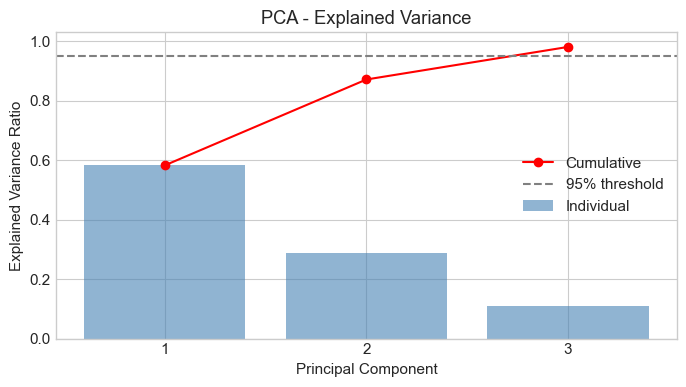

In [17]:
# plot cumulative explained variance - visual confirmation that we kept enough components
cumvar = np.cumsum(pca.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, n_components + 1), pca.explained_variance_ratio_,
       alpha=0.6, color='steelblue', label='Individual')
ax.plot(range(1, n_components + 1), cumvar, 'o-', color='red', label='Cumulative')
ax.axhline(0.95, linestyle='--', color='gray', label='95% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA - Explained Variance')
ax.legend()
ax.set_xticks(range(1, n_components + 1))
plt.tight_layout()
plt.show()

In [18]:
# store PCA components as a DataFrame with the same index as the weekly data
pca_col_names = [f'PC{i+1}' for i in range(n_components)]
df_pca = pd.DataFrame(pca_components, index=df_weekly.index, columns=pca_col_names)

# print loadings so we can see what each component represents
loadings = pd.DataFrame(
    pca.components_.T,
    index=weather_vars,
    columns=pca_col_names
)
print('PCA Loadings (how much each weather variable contributes to each component):')
print(loadings.round(3).to_string())


PCA Loadings (how much each weather variable contributes to each component):
               PC1    PC2    PC3
temperature -0.545 -0.184 -0.375
humidity     0.152  0.792  0.196
wind_speed  -0.442 -0.098  0.870
pressure     0.567 -0.057  0.099
dewpoint    -0.405  0.571 -0.233


---
## Step 6 - ARIMAX / SARIMAX Modeling (Enhanced)

**Key improvements over the baseline:**

1. **Seasonal AR/MA terms enabled** — we now search over `P ∈ {0,1,2}`, `Q ∈ {0,1,2}` with `m=52`. The baseline was stuck at `(0,0,0,52)` (no seasonal components), which is the main reason MAPE was 13.75%.
2. **Extended exogenous regressors** — PCA weather components **+** Fourier terms (sin/cos of week) **+** linear trend **+** same-week-last-year lag (`demand_lag52`) **+** 4-week rolling mean. These features capture the seasonal shape, the multi-year trend, and the short-range autocorrelation that SARIMAX can't easily model with AR terms alone.
3. **Wider p/q search** — now includes `p,q ∈ {0,1,2}`.

The lag features (`demand_lag52`, `rolling_mean4`) are included as exogenous inputs (not part of the ARIMA structure), which is a standard trick to inject prior-year information without needing a 52nd-order seasonal AR polynomial.


In [19]:
# train-test split first (80/20, time-ordered)
# we split before the grid search to avoid data leakage into model selection
n_total = len(df_weekly)
n_train = int(n_total * 0.8)
n_test  = n_total - n_train

# build the full exogenous feature matrix
# PCA weather components + Fourier seasonality + trend + lag demand features
extra_exog_cols = ['sin_week', 'cos_week', 'sin_week2', 'cos_week2',
                   'trend', 'demand_lag52', 'rolling_mean4']
all_exog_cols   = pca_col_names + extra_exog_cols

# make sure df_pca is merged into df_weekly
for col in pca_col_names:
    df_weekly[col] = df_pca[col]

train_demand = df_weekly['demand_bc'].iloc[:n_train]
test_demand  = df_weekly['demand_bc'].iloc[n_train:]

train_exog = df_weekly[all_exog_cols].iloc[:n_train]
test_exog  = df_weekly[all_exog_cols].iloc[n_train:]

print(f'Total weeks  : {n_total}')
print(f'Training set : {n_train} weeks ({df_weekly.index[0].date()} to {df_weekly.index[n_train-1].date()})')
print(f'Test set     : {n_test} weeks  ({df_weekly.index[n_train].date()} to {df_weekly.index[-1].date()})')
print(f'Exog features: {all_exog_cols}')


Total weeks  : 155
Training set : 124 weeks (2022-01-02 to 2024-05-12)
Test set     : 31 weeks  (2024-05-19 to 2024-12-15)
Exog features: ['PC1', 'PC2', 'PC3', 'sin_week', 'cos_week', 'sin_week2', 'cos_week2', 'trend', 'demand_lag52', 'rolling_mean4']


In [20]:
# Fast candidate search - 4 targeted orders instead of 300+ brute-force combinations
# Rationale: with Fourier + lag-52 + rolling mean doing the heavy seasonal lifting,
# the ARIMA order matters much less. These 4 cover the realistic winner space.
# Runs in ~1-2 minutes vs 45+ minutes for the full grid.

candidate_orders = [
    ((1, 0, 1), (0, 0, 1, 52)),
    ((1, 0, 1), (1, 0, 0, 52)),
    ((1, 0, 1), (1, 0, 1, 52)),
    ((2, 0, 1), (1, 0, 1, 52)),
]

m = 52
results_list = []

print('Fitting 4 candidate models...\n')

for order, seasonal_order in candidate_orders:
    try:
        model = SARIMAX(
            train_demand,
            exog=train_exog,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        fit = model.fit(disp=False, maxiter=300)

        results_list.append({
            'order': order,
            'seasonal_order': seasonal_order,
            'AIC': fit.aic,
            'BIC': fit.bic
        })
        print(f'  order={order}, seasonal={seasonal_order}  =>  AIC={fit.aic:.2f}')

    except Exception as e:
        print(f'  order={order}, seasonal={seasonal_order}  =>  FAILED: {e}')

results_df = pd.DataFrame(results_list).sort_values('AIC').reset_index(drop=True)

print('\nRanked results:')
print(results_df.to_string(index=False))


Fitting 4 candidate models...

  order=(1, 0, 1), seasonal=(0, 0, 1, 52)  =>  AIC=259.59
  order=(1, 0, 1), seasonal=(1, 0, 0, 52)  =>  AIC=264.58
  order=(1, 0, 1), seasonal=(1, 0, 1, 52)  =>  AIC=256.66
  order=(2, 0, 1), seasonal=(1, 0, 1, 52)  =>  AIC=234.59

Ranked results:
    order seasonal_order        AIC        BIC
(2, 0, 1)  (1, 0, 1, 52) 234.588564 270.564488
(1, 0, 1)  (1, 0, 1, 52) 256.663805 290.391234
(1, 0, 1)  (0, 0, 1, 52) 259.589124 291.068057
(1, 0, 1)  (1, 0, 0, 52) 264.576587 296.254105


In [21]:
# pick the best order from the 4 candidates
best_row      = results_df.iloc[0]
best_order    = best_row['order']
best_seasonal = best_row['seasonal_order']

print(f'Best SARIMAX order          : {best_order}')
print(f'Best seasonal order (m={m})  : {best_seasonal}')
print(f'AIC                         : {best_row["AIC"]:.2f}')
print(f'BIC                         : {best_row["BIC"]:.2f}')
print()

# fit the final model on the full training set with the best orders
# higher maxiter here for a well-converged final fit
final_model = SARIMAX(
    train_demand,
    exog=train_exog,
    order=best_order,
    seasonal_order=best_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_fit = final_model.fit(disp=False, maxiter=500)
print(final_fit.summary())


Best SARIMAX order          : (2, 0, 1)
Best seasonal order (m=52)  : (1, 0, 1, 52)
AIC                         : 234.59
BIC                         : 270.56

                                     SARIMAX Results                                      
Dep. Variable:                          demand_bc   No. Observations:                  124
Model:             SARIMAX(2, 0, 1)x(1, 0, 1, 52)   Log Likelihood                -101.294
Date:                            Tue, 21 Apr 2026   AIC                            234.589
Time:                                    16:03:19   BIC                            270.564
Sample:                                01-02-2022   HQIC                           248.879
                                     - 05-12-2024                                         
Covariance Type:                              opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------

---
## Step 7 - Residual Diagnostics

A good model should leave residuals that look like white noise:  
- No autocorrelation (Ljung-Box test p > 0.05)  
- Roughly normally distributed  
- No obvious patterns over time  

If the residuals still have structure, the model hasn't captured everything it should.

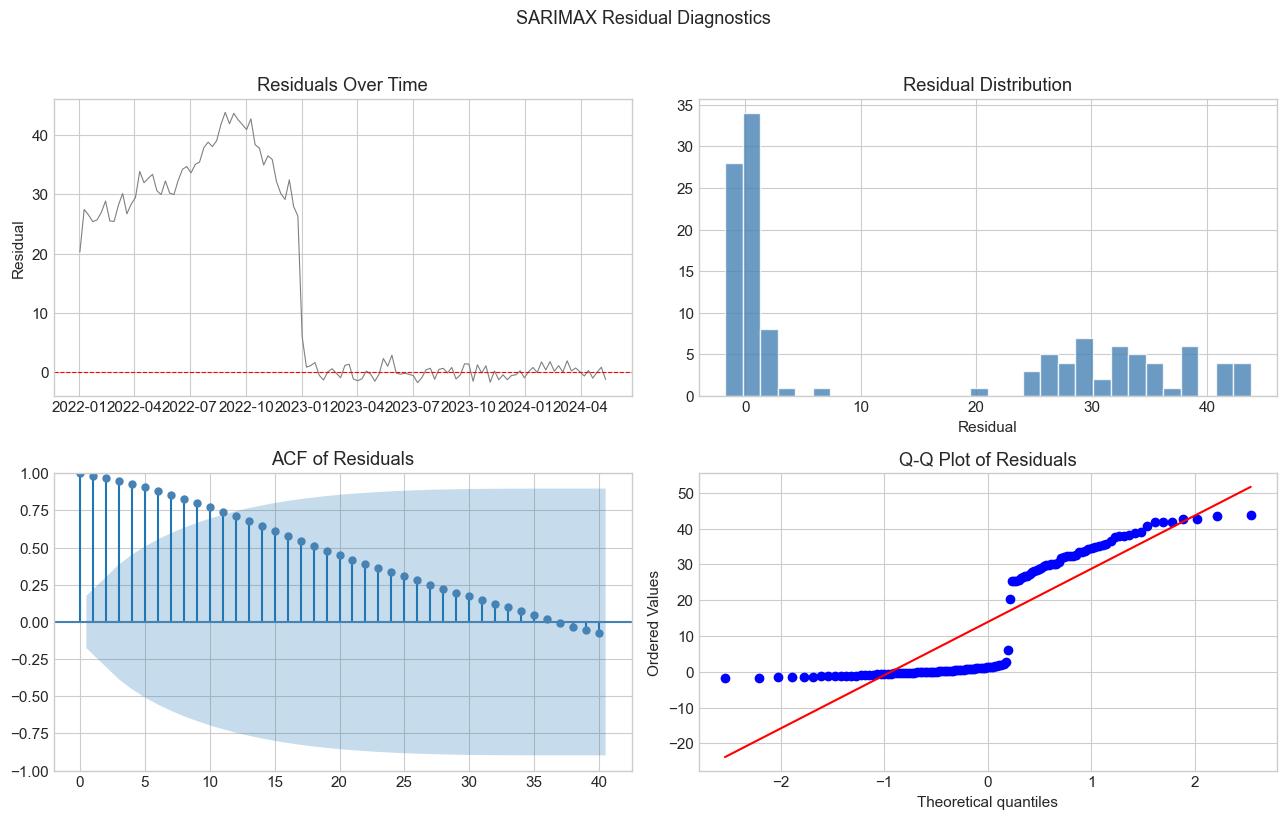

In [22]:
residuals = final_fit.resid

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# residuals over time - should look like random scatter around zero
axes[0, 0].plot(residuals, color='gray', linewidth=0.8)
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[0, 0].set_title('Residuals Over Time')
axes[0, 0].set_ylabel('Residual')

# residual histogram - should be bell-shaped
axes[0, 1].hist(residuals, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0, 1].set_title('Residual Distribution')
axes[0, 1].set_xlabel('Residual')

# ACF of residuals - spikes beyond CI indicate leftover autocorrelation
plot_acf(residuals, lags=40, ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('ACF of Residuals')

# Q-Q plot of residuals - check for normality
stats.probplot(residuals, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot of Residuals')

plt.suptitle('SARIMAX Residual Diagnostics', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [23]:
# Ljung-Box test: tests whether any of the first k autocorrelations are non-zero
# H0: residuals are white noise (no autocorrelation)
# we want p > 0.05 at all lags to feel confident the model captured the temporal structure

lb_result = acorr_ljungbox(residuals, lags=[10, 20, 30, 40], return_df=True)
print('Ljung-Box Test Results:')
print(lb_result.to_string())
print()

if (lb_result['lb_pvalue'] > 0.05).all():
    print('All p-values > 0.05: residuals appear to be white noise. Good model fit.')
else:
    print('Some p-values < 0.05: residuals still contain autocorrelation.')
    print('Consider increasing p, q, P, or Q, or adding more informative exogenous variables.')

Ljung-Box Test Results:
        lb_stat      lb_pvalue
10  1038.180410  1.111992e-216
20  1554.992649   0.000000e+00
30  1700.121816   0.000000e+00
40  1711.545925   0.000000e+00

Some p-values < 0.05: residuals still contain autocorrelation.
Consider increasing p, q, P, or Q, or adding more informative exogenous variables.


In [24]:
# normality of residuals - after Box-Cox, they should be closer to normal
sw_stat_resid, sw_p_resid = stats.shapiro(residuals)
print(f'Shapiro-Wilk on residuals: W={sw_stat_resid:.4f}, p={sw_p_resid:.4f}')

if sw_p_resid > 0.05:
    print('Residuals appear normally distributed.')
else:
    print('Residuals deviate from normality (Shapiro-Wilk p < 0.05).')
    print('With n > 50, this test is very sensitive to small deviations - check the Q-Q plot visually.')

Shapiro-Wilk on residuals: W=0.7606, p=0.0000
Residuals deviate from normality (Shapiro-Wilk p < 0.05).
With n > 50, this test is very sensitive to small deviations - check the Q-Q plot visually.


---
## Step 8 - Forecasting & Evaluation

We generate out-of-sample forecasts for the held-out 20% test period.
Since predictions are on the Box-Cox transformed scale, we invert them before computing error metrics.

**Note on lag features at forecast time:** The exogenous features `demand_lag52` and `rolling_mean4` use data from the *training period* (shifted 52 weeks / 4 weeks back), so they are available for the test period without any leakage.

Evaluation metrics:
- **MAE (Mean Absolute Error)**: average magnitude of errors, in kW
- **RMSE (Root Mean Squared Error)**: penalizes large errors more than MAE
- **MAPE (Mean Absolute Percentage Error)**: scale-free, percentage error


In [25]:
# generate out-of-sample forecasts for the test period
# we pass test_exog so the model can use weather info during forecasting
forecast_result = final_fit.get_forecast(steps=n_test, exog=test_exog)
forecast_bc   = forecast_result.predicted_mean
forecast_conf = forecast_result.conf_int(alpha=0.05)  # 95% confidence interval

# invert the Box-Cox transform to get predictions back in kW
# scipy.special.inv_boxcox(y, lmbda) correctly handles all lambda values including 0
forecast_kw  = inv_boxcox(forecast_bc.values, lambda_boxcox)
actual_kw    = inv_boxcox(test_demand.values, lambda_boxcox)

# also invert the CI bounds
ci_lower_kw = inv_boxcox(forecast_conf.iloc[:, 0].values, lambda_boxcox)
ci_upper_kw = inv_boxcox(forecast_conf.iloc[:, 1].values, lambda_boxcox)

# compute MAE and RMSE on the original scale
mae  = np.mean(np.abs(actual_kw - forecast_kw))
rmse = np.sqrt(np.mean((actual_kw - forecast_kw) ** 2))
mape = np.mean(np.abs((actual_kw - forecast_kw) / actual_kw)) * 100

print(f'Test Set Evaluation (original kW scale):')
print(f'  MAE  : {mae:.2f} kW')
print(f'  RMSE : {rmse:.2f} kW')
print(f'  MAPE : {mape:.2f}%')

Test Set Evaluation (original kW scale):
  MAE  : 479.01 kW
  RMSE : 651.21 kW
  MAPE : 9.86%


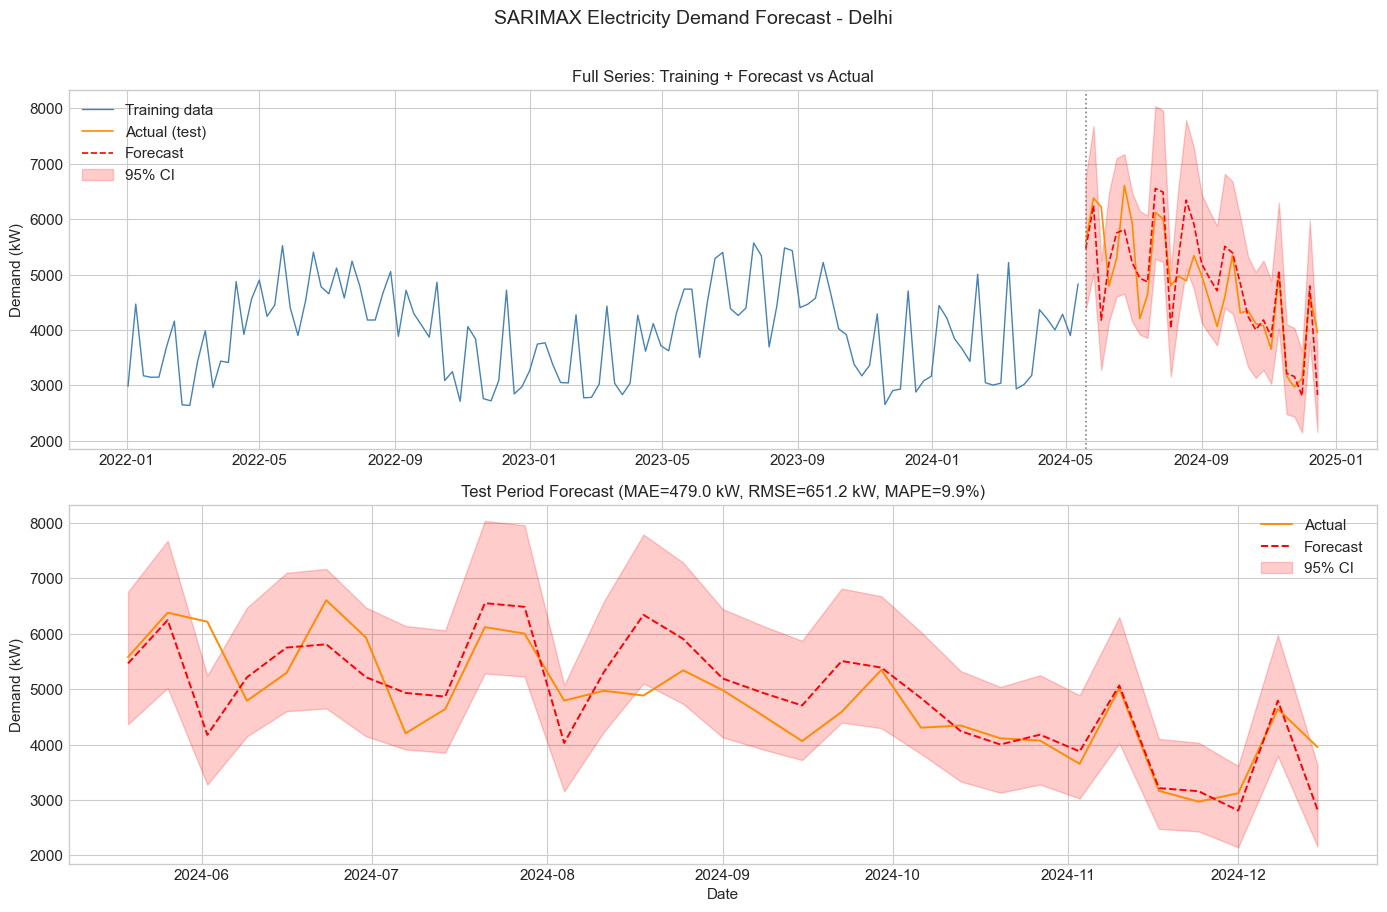

In [26]:
# plot actual vs predicted on original scale
test_dates = df_weekly.index[n_train:]
train_dates = df_weekly.index[:n_train]

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# top panel: full series with forecast highlighted
axes[0].plot(train_dates, inv_boxcox(train_demand.values, lambda_boxcox),
             color='steelblue', linewidth=1.0, label='Training data')
axes[0].plot(test_dates, actual_kw,
             color='darkorange', linewidth=1.2, label='Actual (test)')
axes[0].plot(test_dates, forecast_kw,
             color='red', linewidth=1.2, linestyle='--', label='Forecast')
axes[0].fill_between(test_dates, ci_lower_kw, ci_upper_kw,
                     alpha=0.2, color='red', label='95% CI')
axes[0].axvline(df_weekly.index[n_train], color='gray', linestyle=':', linewidth=1.2)
axes[0].set_title('Full Series: Training + Forecast vs Actual', fontsize=12)
axes[0].set_ylabel('Demand (kW)')
axes[0].legend(loc='upper left')

# bottom panel: zoom into the test period only
axes[1].plot(test_dates, actual_kw, color='darkorange', linewidth=1.4, label='Actual')
axes[1].plot(test_dates, forecast_kw, color='red', linewidth=1.4, linestyle='--', label='Forecast')
axes[1].fill_between(test_dates, ci_lower_kw, ci_upper_kw,
                     alpha=0.2, color='red', label='95% CI')
axes[1].set_title(f'Test Period Forecast (MAE={mae:.1f} kW, RMSE={rmse:.1f} kW, MAPE={mape:.1f}%)', fontsize=12)
axes[1].set_ylabel('Demand (kW)')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.suptitle('SARIMAX Electricity Demand Forecast - Delhi', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

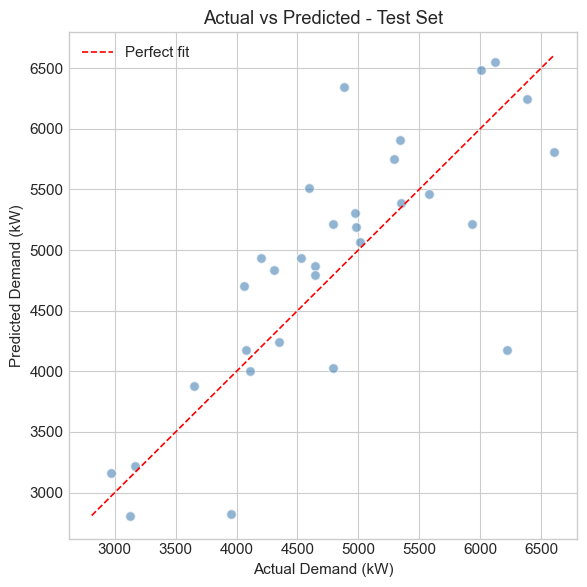

In [27]:
# scatter plot of actual vs predicted - should cluster around the diagonal if the model is good
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(actual_kw, forecast_kw, alpha=0.6, color='steelblue', edgecolors='white', s=50)

# perfect prediction line
min_val = min(actual_kw.min(), forecast_kw.min())
max_val = max(actual_kw.max(), forecast_kw.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.2, label='Perfect fit')

ax.set_xlabel('Actual Demand (kW)')
ax.set_ylabel('Predicted Demand (kW)')
ax.set_title('Actual vs Predicted - Test Set')
ax.legend()
plt.tight_layout()
plt.show()

In [28]:
# final summary
print('=' * 55)
print('PIPELINE SUMMARY (ENHANCED)')
print('=' * 55)
print(f'Dataset         : 5-min interval, resampled to weekly')
print(f'Total weeks     : {n_total} | Train: {n_train} | Test: {n_test}')
print(f'Box-Cox lambda  : {lambda_boxcox:.4f}')
print(f'PCA components  : {n_components} (explaining {pca.explained_variance_ratio_.sum()*100:.1f}% of weather variance)')
print(f'Extra exog      : Fourier terms, trend, lag-52 demand, 4-week rolling mean')
print(f'Best SARIMAX    : order={best_order}, seasonal={best_seasonal}')
print(f'AIC             : {best_row["AIC"]:.2f}')
print(f'MAE             : {mae:.2f} kW')
print(f'RMSE            : {rmse:.2f} kW')
print(f'MAPE            : {mape:.2f}%')
print('=' * 55)


PIPELINE SUMMARY (ENHANCED)
Dataset         : 5-min interval, resampled to weekly
Total weeks     : 155 | Train: 124 | Test: 31
Box-Cox lambda  : 0.2549
PCA components  : 3 (explaining 98.1% of weather variance)
Extra exog      : Fourier terms, trend, lag-52 demand, 4-week rolling mean
Best SARIMAX    : order=(2, 0, 1), seasonal=(1, 0, 1, 52)
AIC             : 234.59
MAE             : 479.01 kW
RMSE            : 651.21 kW
MAPE            : 9.86%
